In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape

(920, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
df=df.drop(columns=['id'])

In [ ]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [ ]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [ ]:
df['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality', nan], dtype=object)

In [ ]:
df['fbs'].unique()

array([True, False, nan], dtype=object)

In [ ]:
df['exang'].unique()

array([False, True, nan], dtype=object)

In [ ]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping', nan], dtype=object)

In [ ]:
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect', nan], dtype=object)

In [ ]:
numeric_cols=df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
  df[col].fillna(df[col].median(),inplace=True)

categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_509/2954860235.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)
/tmp/ipykernel_509/2954860235.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


In [ ]:
df.select_dtypes(include='object').columns

Index(['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal'], dtype='object')

In [ ]:
df=df.drop(columns=['dataset'])

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    bool   
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    bool   
 6   oldpeak                   920 non-null    float64
 7   ca                        920 non-null    float64
 8   num                       920 non-null    int64  
 9   sex_Male                  920 non-null    bool   
 10  cp_atypical angina        920 non-null    bool   
 11  cp_non-anginal            920 non-null    bool   
 12  cp_typical angina         920 non-null    bool   
 13  restecg_normal            920 non-null    bool   
 14  restecg_st

In [ ]:
df['num']=df['num'].apply(lambda x:0 if x==0 else 1)

In [ ]:
df['num'].value_counts()

,count
num,
1,509
0,411


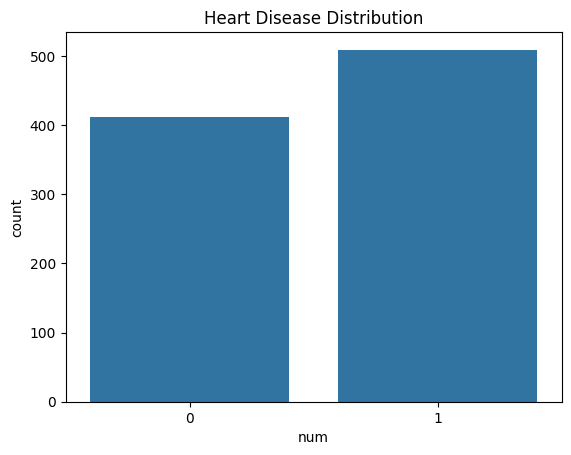

In [ ]:
sns.countplot(x=df['num'])
plt.title("Heart Disease Distribution")
plt.show()

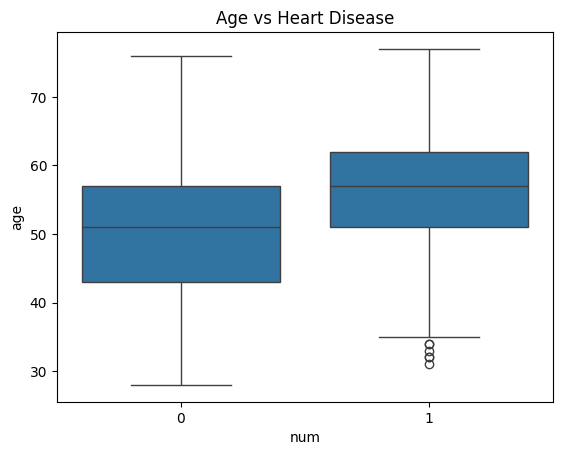

In [ ]:
sns.boxplot(x=df['num'],y=df['age'])
plt.title("Age vs Heart Disease")
plt.show()

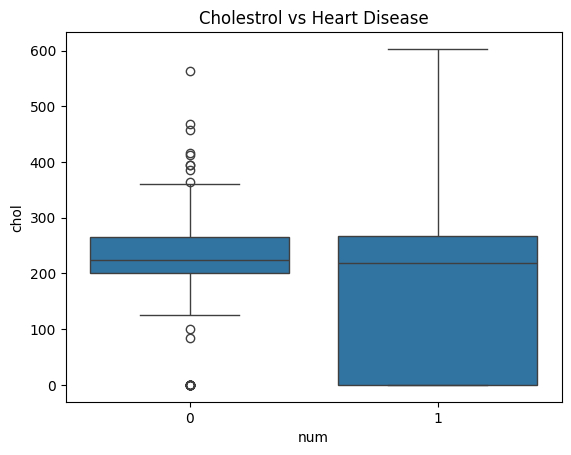

In [ ]:
sns.boxplot(x=df['num'],y=df['chol'])
plt.title("Cholestrol vs Heart Disease")
plt.show()

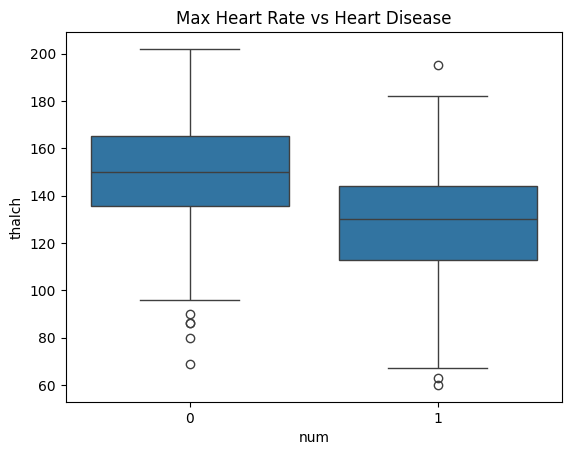

In [ ]:
sns.boxplot(x=df['num'],y=df['thalch'])
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

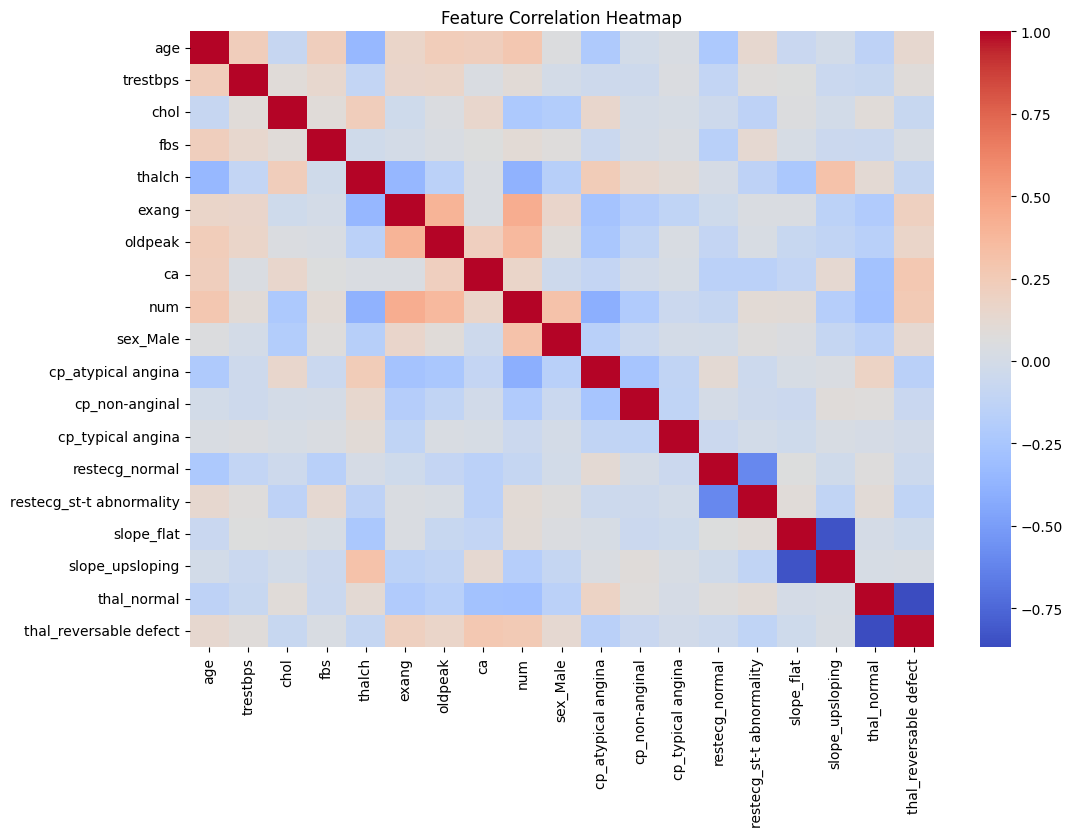

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

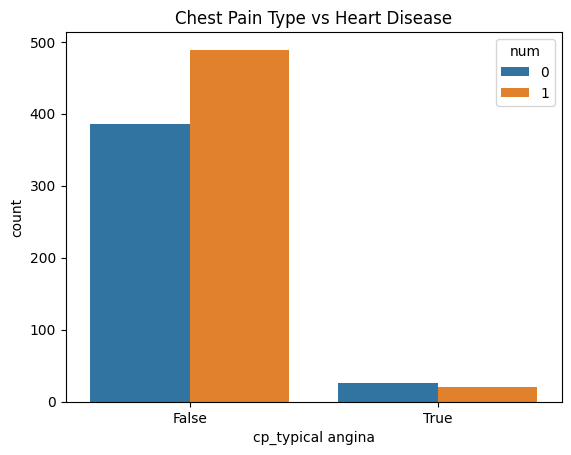

In [ ]:
sns.countplot(x='cp_typical angina',hue="num",data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [ ]:
x=df.drop("num",axis=1)
y=df['num']

In [ ]:
x.shape


(920, 18)

In [ ]:
y.shape

(920,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(736, 18)
(736,)
(184, 18)
(184,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
x_train[:5]

array([[ 0.90241255, -0.08394637, -0.26257507, -0.40110258, -0.69418678,
         1.32146459,  1.9836244 , -0.36137006,  0.50593744, -0.48252546,
        -0.53335515, -0.23007121, -1.21235253,  2.04526247,  0.67206884,
        -0.55223595,  0.57525841, -0.49745113],
       [ 0.03477619,  0.98777137,  0.22365937, -0.40110258, -0.6149987 ,
        -0.75673613, -0.79440597, -0.36137006,  0.50593744, -0.48252546,
         1.87492331, -0.23007121,  0.82484259, -0.4889348 ,  0.67206884,
        -0.55223595,  0.57525841, -0.49745113],
       [-0.29058745, -0.08394637,  1.28787059, -0.40110258,  0.09769399,
        -0.75673613, -0.33140091, -0.36137006,  0.50593744, -0.48252546,
         1.87492331, -0.23007121,  0.82484259, -0.4889348 ,  0.67206884,
        -0.55223595,  0.57525841, -0.49745113],
       [-0.39904199, -0.61980524,  0.18696243, -0.40110258,  0.81038667,
        -0.75673613,  0.68721023, -0.36137006, -1.97652894, -0.48252546,
         1.87492331, -0.23007121,  0.82484259, -0.488

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_predict = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_predict)
print("Accuracy:",accuracy)

Accuracy: 0.7989130434782609


In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix=confusion_matrix(y_test,y_predict)
print(conf_matrix)

[[60 15]
 [22 87]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        75
           1       0.85      0.80      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.80      0.80       184



In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)
y_predict_dt=dt_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Decision Tree Accuracy:",accuracy_score(y_test,y_predict_dt))
print(confusion_matrix(y_test,y_predict_dt))
print(classification_report(y_test,y_predict_dt))

Decision Tree Accuracy: 0.7934782608695652
[[59 16]
 [22 87]]
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        75
           1       0.84      0.80      0.82       109

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
y_predict_rf=rf_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print("Random Forest Accuracy:",accuracy_score(y_test,y_predict_rf))
print(confusion_matrix(y_test,y_predict_rf))
print(classification_report(y_test,y_predict_rf))

Random Forest Accuracy: 0.8695652173913043
[[66  9]
 [15 94]]
              precision    recall  f1-score   support

           0       0.81      0.88      0.85        75
           1       0.91      0.86      0.89       109

    accuracy                           0.87       184
   macro avg       0.86      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_predict_knn=knn_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("KNN Accuracy:",accuracy_score(y_test,y_predict_knn))
print (confusion_matrix(y_test,y_predict_knn))
print(classification_report(y_test,y_predict_knn))

KNN Accuracy: 0.8097826086956522
[[62 13]
 [22 87]]
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        75
           1       0.87      0.80      0.83       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.81       184
weighted avg       0.82      0.81      0.81       184



In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(use_label_encoder=False,eval_metric='logloss')
xgb_model.fit(x_train,y_train)
y_predict_xgb=xgb_model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:43:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_predict_xgb))
print(confusion_matrix(y_test, y_predict_xgb))
print(classification_report(y_test, y_predict_xgb))

XGBoost Accuracy: 0.875
[[66  9]
 [14 95]]
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        75
           1       0.91      0.87      0.89       109

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



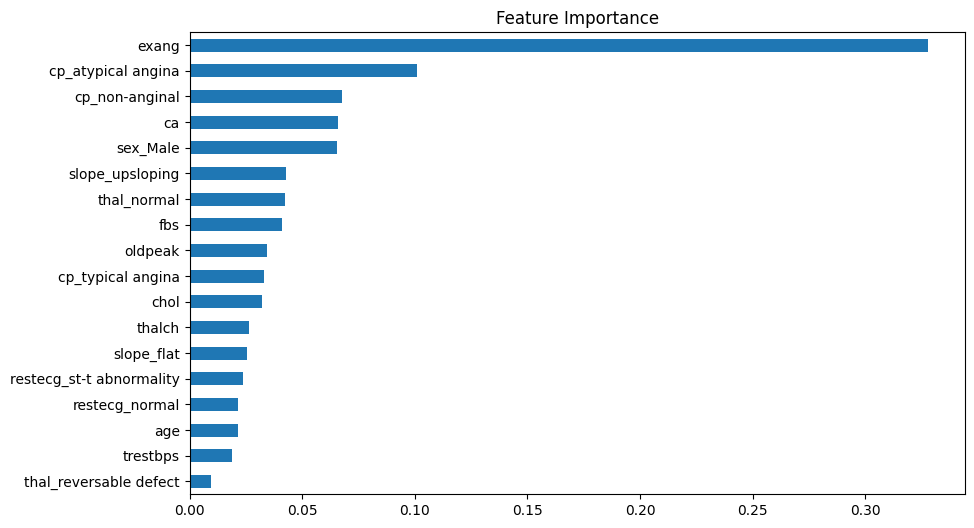

In [ ]:
importance = xgb_model.feature_importances_
feature_names=x.columns
feat_importance=pd.Series(importance,index=feature_names)
feat_importance.sort_values().plot(kind='barh',figsize=(10,6))
plt.title("Feature Importance")
plt.show()

In [ ]:
model_results=pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest","KNN","XGBoost"],
    "Accuracy":[0.80,0.79,0.81,0.87,0.875]

})
model_results

,Model,Accuracy
0,Logistic Regression,0.800
1,Decision Tree,0.790
2,Random Forest,0.810
3,KNN,0.870
4,XGBoost,0.875
